In [2]:
# lets import libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re
import os
import joblib
from wordcloud import WordCloud
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble  import RandomForestClassifier
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings('ignore')

In [3]:
# lets download text preprocessing tools from nltk
nltk.download('stopwords',quiet=True)
nltk.download('wordnet',quiet=True)
nltk.download('punkt',quiet=True)
nltk.download('punkt_tab',quiet=True)

True

In [4]:
# set stopwords in english and calling object
stop_words = set(stopwords.words('english'))
lematizer = WordNetLemmatizer()

In [5]:
# importing dataset   
data = pd.read_csv(r'C:\Users\ejjig\OneDrive\Desktop\NLP\IMDB Dataset.csv')

## Basic data understanding

In [6]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [8]:
data.shape

(50000, 2)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [10]:
# checking class distribution
data['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

## Text cleaning

In [11]:
def preprocess_text(text):
    
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r"\S*@\S*", '', text)
    text = re.sub(r'\bbr\b', '',text)
    text = re.sub(r'[^a-zA-Z\s!?:;\'"]', ' ', text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    
    # stop words removal
    filter_words = []
    for word in text.split():
        if word not in stop_words:
            filter_words.append(word)
            
    filter_words
    
    # lemmatization
    lematize_words = [lematizer.lemmatize(word) for word in filter_words]
    lematize_words
    
    return ' '.join(lematize_words)
    

In [12]:
# removing these words from stopwords for a better context
stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("never")
stop_words.discard("nor")

In [13]:
data['cleaned_review'] = data['review'].apply(preprocess_text)

In [14]:
data.head()

,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there's family little boy jake think...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"petter mattei's ""love time money"" visually stu..."


## EDA


## Word clouds

In [15]:
# most frequent words to less frequent words in positive sentiment)
positive_review = ' '.join(data[data['sentiment']== 'positive']['cleaned_review'])

positive_wc = WordCloud(width=850,height=350,background_color='white').generate(positive_review)


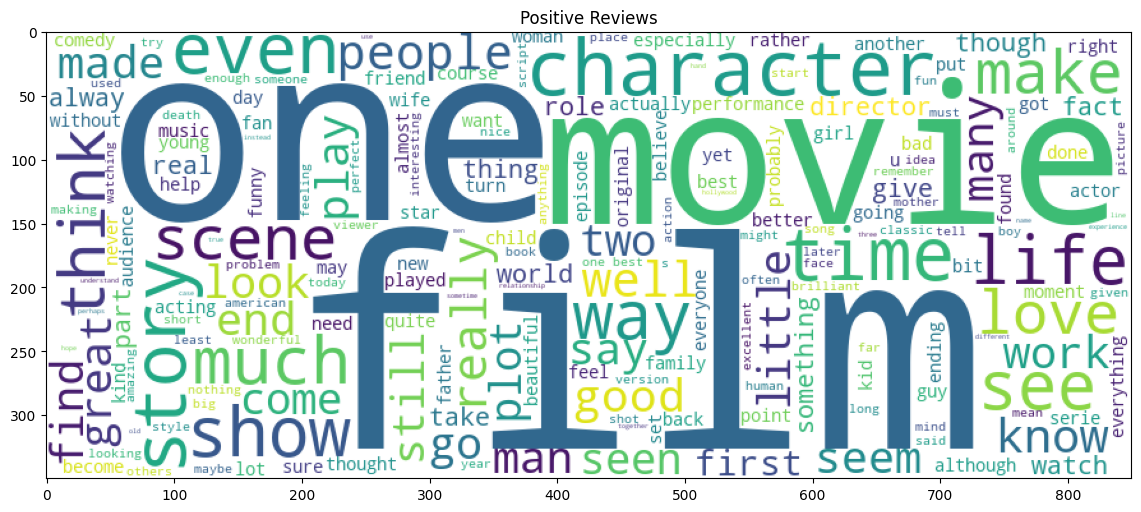

In [16]:
# visualize
plt.figure(figsize=(14,8))
plt.title('Positive Reviews')
plt.imshow(positive_wc,)
plt.show()

In [17]:
# negative reviews
negative_reviews = ' '.join(data[data['sentiment']=='negative']['cleaned_review'])
negative_wc =  WordCloud(width=850,height=350,background_color='white').generate(negative_reviews)

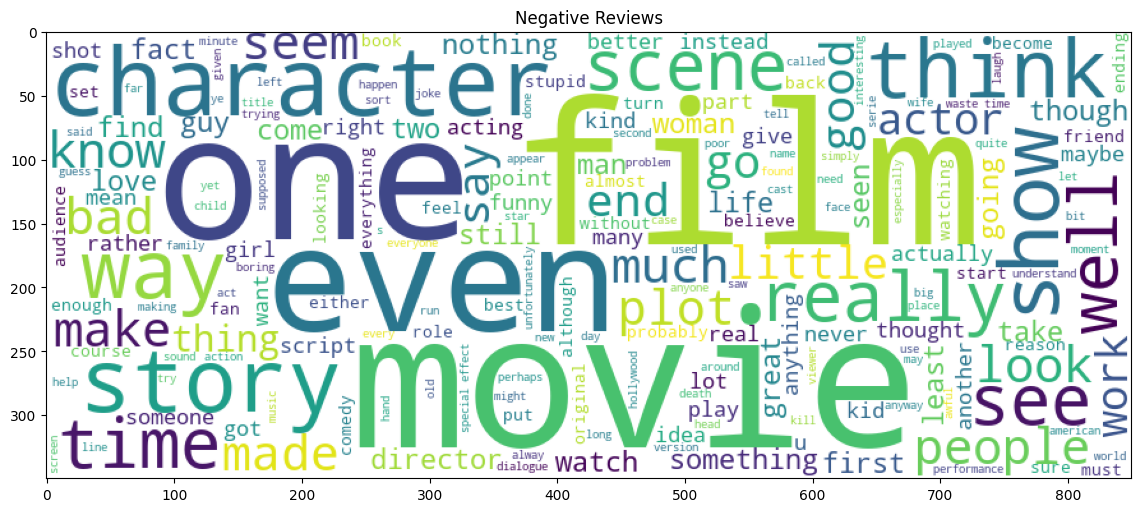

In [18]:
# visualize
plt.figure(figsize=(14,8))
plt.title('Negative Reviews')
plt.imshow(negative_wc)
plt.show()

In [19]:
# lets count top frequent words in the review
count_words = ' '.join(data['cleaned_review']).split()
Counter(count_words).most_common(30)

[('not', 119594),
 ('movie', 99563),
 ('film', 89556),
 ('one', 54105),
 ('like', 40889),
 ('would', 31138),
 ('time', 30587),
 ('good', 28979),
 ('character', 27187),
 ('no', 24858),
 ('even', 24839),
 ('story', 24480),
 ('get', 24326),
 ('make', 24099),
 ('see', 23721),
 ('really', 22950),
 ('well', 21056),
 ('scene', 20971),
 ('much', 19161),
 ('could', 18546),
 ('also', 17939),
 ('great', 17834),
 ('bad', 17791),
 ('people', 17616),
 ('first', 17447),
 ('way', 16877),
 ('show', 16712),
 ('thing', 15902),
 ('made', 15899),
 ('think', 15133)]

## split into X and y

In [20]:
X = data['cleaned_review']
y = data['sentiment']

## train test split

In [21]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)

## Vectorization

In [22]:
# bow 
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X_train_bow = cv.fit_transform(X_train)
X_test_bow = cv.transform(X_test)


## train


In [23]:
# training models
models = {'Logistic Regressioon': LogisticRegression(),
          'Naive Bayes': MultinomialNB(),
          'Random Forest Classifier': RandomForestClassifier(),
          'SVM' : LinearSVC(),
          'KNN': KNeighborsClassifier()}


for name, model in models.items():
    model.fit(X_train_bow,y_train)
    y_pred = model.predict(X_test_bow)
    
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_test,y_pred)
    print(f'{name}:{acc}')

Logistic Regressioon:0.8845
Naive Bayes:0.8586
Random Forest Classifier:0.8557
SVM:0.8639
KNN:0.6332


In [24]:
best_model = models['Logistic Regressioon']

In [25]:
joblib.dump(best_model,'sentiment_analyzer.pkl')

['sentiment_analyzer.pkl']

In [26]:
joblib.dump(cv,'bow_vectorizer.pkl')

['bow_vectorizer.pkl']

## TF-IDF

In [27]:
# tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [28]:
# training models
models = {'Logistic Regressioon': LogisticRegression(),
          'Naive Bayes': MultinomialNB(),
          'Random Forest Classifier': RandomForestClassifier(),
          'SVM' : LinearSVC(),
          'KNN': KNeighborsClassifier()}


for name, model in models.items():
    model.fit(X_train_tfidf,y_train)
    y_pred = model.predict(X_test_tfidf)
    
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_test,y_pred)
    print(f'{name}:{acc}')

Logistic Regressioon:0.8978
Naive Bayes:0.8661
Random Forest Classifier:0.8517
SVM:0.8949
KNN:0.7816


In [29]:
best_models = models['Logistic Regressioon']

In [ ]:
joblib.dump(best_models,'sentiment_tfidf.pkl')

['sentiment_tfidf.pkl']

In [31]:
joblib.dump(tfidf,'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

## Tf-idf with ngrams(uni + bigrams)

In [34]:
# tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=50000
)


X_traintfidf_bi = tfidf.fit_transform(X_train)
X_testtfidf_bi = tfidf.transform(X_test)

In [35]:
# training models
models = {'Logistic Regressioon': LogisticRegression(),
          'Naive Bayes': MultinomialNB(),
          'Random Forest Classifier': RandomForestClassifier(),
          'SVM' : LinearSVC(),
          'KNN': KNeighborsClassifier()}


for name, model in models.items():
    model.fit(X_traintfidf_bi,y_train)
    y_pred = model.predict(X_testtfidf_bi)
    
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_test,y_pred)
    print(f'{name}:{acc}')

Logistic Regressioon:0.902
Naive Bayes:0.8837
Random Forest Classifier:0.866
SVM:0.9066
KNN:0.7767


In [36]:
best_modelss = models['SVM']

In [37]:
joblib.dump(best_modelss,'sentiment_tfidf_ngrams.pkl')

['sentiment_tfidf_ngrams.pkl']

In [38]:
joblib.dump(tfidf,'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']